# Notebook 06 — ELT Generation & Full Pipeline Round-Trip
**Project: Coastal Property Catastrophe Loss Model**

**This is the key notebook.** We take our trained frequency and severity models, run them on a portfolio of properties, and convert the predictions into an **Event Loss Table (ELT)** — the industry-standard format consumed by catastrophe pricing engines.

We then feed that ELT directly into our `MarginalPMLEngine` to produce portfolio PML estimates at multiple return periods.

## The Bridge
```
NFIP Claims Data
      ↓
  FeaturePipeline          → 17 engineered features
      ↓
  FrequencyModel           → RATE  (annual claim probability)
  SeverityModel            → PERSPVALUE  (expected loss | event)
      ↓
  ELTGenerator             → EVENTID, RATE, PERSPVALUE, EXPVALUE, STDDEVC, STDDEVI
      ↓
  MarginalPMLEngine        → PML at 1-in-50, 1-in-100, 1-in-250 year return periods
```

The ELT format is **interchangeable** with output from commercial cat models (AIR, RMS, CoreLogic). The same pricing engine runs on both.

## ELT Column Mapping
| ELT Column | Source | Meaning |
|---|---|---|
| `RATE` | FrequencyModel.predict_proba() × filing_rate | Annual P(claim) |
| `PERSPVALUE` | SeverityModel.predict_with_uncertainty().mean | E[loss \| event] |
| `EXPVALUE` | totalBuildingInsuranceCoverage | Policy limit / TIV |
| `STDDEVC` | total_std × corr_fraction | Correlated (systematic) variance |
| `STDDEVI` | total_std × √(1-corr²) | Idiosyncratic variance |

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from feature_engineering import FeaturePipeline
from severity_model import SeverityModel
from frequency_model import FrequencyModel
from elt_generator import ELTGenerator, validate_elt, build_elt_from_claims
from data_ingestion import load_filing_rates

DATA_DIR  = Path('../data/raw')
MODEL_DIR = Path('../models')

print('✅ Imports OK')

✅ Imports OK


## 1. Load Models & Data

In [2]:
# Load trained models
sev_model  = SeverityModel.load(str(MODEL_DIR / 'severity_model.joblib'))
freq_model = FrequencyModel.load(str(MODEL_DIR / 'frequency_model.joblib'))

print(f'Severity model loaded  | train log RMSE (σ): {sev_model.train_log_rmse:.4f}')
print(f'Frequency model loaded | baseline rate:      {freq_model.baseline_rate:.1%}')

# Load enriched claims as our "new property portfolio"
claims = pd.read_parquet(DATA_DIR / 'nfip_claims_enriched.parquet')

# Use a representative 10K sample as our pricing portfolio
portfolio_raw = claims.sample(10_000, random_state=42).reset_index(drop=True)
print(f'\nPortfolio sample: {len(portfolio_raw):,} properties')
print(f'Flood zones: {portfolio_raw["flood_zone_category"].value_counts().to_dict()}')

Severity model loaded  | train log RMSE (σ): 1.0307
Frequency model loaded | baseline rate:      76.9%

Portfolio sample: 10,000 properties
Flood zones: {'unknown': 5223, 'high_risk': 3389, 'moderate_risk': 1130, 'coastal_high_risk': 214, 'minimal_risk': 44}


## 2. Generate Feature Matrix

In [3]:
pipeline = FeaturePipeline(reference_year=2023)
X_portfolio, _, _ = pipeline.fit_transform(portfolio_raw, return_targets=False)

print(f'Feature matrix: {X_portfolio.shape}')

Feature matrix: (10000, 20)


## 3. Generate ELT from ML Predictions

In [4]:
# Load filing rates (computed in notebook 01 from OpenFEMA policies)
# These convert P(paid|filed) → true annual claim rate
filing_rates = load_filing_rates(str(DATA_DIR / 'filing_rates.parquet'))
print(f'Filing rates loaded: {len(filing_rates)} rows')
print(filing_rates[filing_rates['state'] == '_ALL'][['flood_zone_category', 'filing_rate']].to_string(index=False))
print()

generator = ELTGenerator(
    freq_model=freq_model,
    sev_model=sev_model,
    corr_method='both',  # Average flood zone + peril corr fractions
    filing_rates=filing_rates,  # Scale P(paid|filed) by filing rate
)

# ── Step A: Property-level ELT (for analysis / rate breakdown) ────────────
prop_elt = generator.generate(
    X_portfolio,
    metadata=portfolio_raw,
    property_ids=portfolio_raw.index.astype(str),
    portfolio_name='nfip_portfolio',
)
print(f'Property-level ELT: {len(prop_elt):,} rows')

# ── Step B: Zone-aggregated Portfolio ELT (for PML engine) ────────────────
# Properties in the same flood zone are grouped into shared catastrophe events.
# This captures the reality that a hurricane/flood hits ALL properties in a zone
# simultaneously, producing much larger single-event losses and proper tail
# separation at high return periods (250yr → 500yr).
#
# Aggregation rules per zone:
#   RATE       = max(individual rates)  — zone event fires if ANY property is hit
#   PERSPVALUE = Σ(individual means)    — total expected zone loss
#   EXPVALUE   = Σ(individual TIVs)     — total zone exposure
#   STDDEVC    = Σ(individual STDDEVC)  — fully correlated: linear sum
#   STDDEVI    = √Σ(individual STDDEVI²) — independent: quadrature sum
elt = generator.generate_portfolio_elt(
    X_portfolio,
    metadata=portfolio_raw,
    group_by_zone=True,
)

print(f'\nZone-aggregated ELT: {len(elt):,} events (one per flood zone)')
print(elt.to_string(index=False))

print(f'\n→ Property-level ELT kept as prop_elt for rate/severity analysis')
print(f'→ Zone-aggregated ELT used for PML engine (captures correlated losses)')

Filing rates not found at ..\data\raw\filing_rates.parquet. Using literature-based fallback.


Filing rates loaded: 5 rows
flood_zone_category  filing_rate
  coastal_high_risk        0.085
          high_risk        0.042
      moderate_risk        0.015
       minimal_risk        0.008
            unknown        0.035

Property-level ELT: 10,000 rows

Zone-aggregated ELT: 5 events (one per flood zone)
               EVENTID     RATE   PERSPVALUE     EXPVALUE      STDDEVC      STDDEVI
zone_coastal_high_risk 0.081625 1.370402e+07  285221002.0 1.339112e+07 3.402831e+06
        zone_high_risk 0.040762 1.801035e+08 1101134336.0 1.401932e+08 5.782571e+06
     zone_minimal_risk 0.013898 2.160347e+06    9127500.0 1.261327e+06 4.952015e+05
    zone_moderate_risk 0.014460 5.486029e+07  366876920.0 3.341113e+07 3.310549e+06
          zone_unknown 0.014514 2.138926e+08 1166124006.0 1.459760e+08 5.982398e+06

→ Property-level ELT kept as prop_elt for rate/severity analysis
→ Zone-aggregated ELT used for PML engine (captures correlated losses)


## 3b. Rate Calculation Breakdown

This cell shows exactly how the raw frequency model output is scaled down to produce
a realistic annual claim rate for the ELT `RATE` column:

```
annual_rate  =  P(paid | filed)   ×   filing_rate
               [freq model ~0.77]     [OpenFEMA 0.015–0.085]
               ────────────────────────────────────────────
               result: ~0.01 – 0.07  (1% – 7% per year)
```

Without this scaling the ELT `RATE` would be ~40× too high, overstating annual
frequencies and producing nonsensical PML numbers.

In [5]:
# ── Step 1: raw frequency model output ─────────────────────────────────────
p_paid_raw = freq_model.predict_proba(X_portfolio)

# ── Step 2: filing rate per property (from OpenFEMA policies) ──────────────
filing_rate_arr = generator._lookup_filing_rates(X_portfolio)

# ── Step 3: scaled annual rate = what ends up in property-level ELT RATE column
annual_rate = prop_elt['RATE'].values

print('Rate Calculation Breakdown')
print('=' * 58)
print('  Step 1 — Frequency model  P(paid | filed):')
print(f'    mean  = {p_paid_raw.mean():.3f}  ({p_paid_raw.mean()*100:.1f}%)')
print(f'    range = {p_paid_raw.min():.3f} – {p_paid_raw.max():.3f}')
print()
print('  Step 2 — Filing rate  P(filed | property-year)  [from OpenFEMA policies]:')
print(f'    mean  = {filing_rate_arr.mean():.4f}  ({filing_rate_arr.mean()*100:.2f}%)')
print(f'    range = {filing_rate_arr.min():.4f} – {filing_rate_arr.max():.4f}')
print()
print('  Step 3 — ELT RATE = Step 1 × Step 2  (true annual claim rate):')
print(f'    mean  = {annual_rate.mean():.4f}  ({annual_rate.mean()*100:.2f}%)')
print(f'    P10   = {np.percentile(annual_rate, 10):.4f}  ({np.percentile(annual_rate, 10)*100:.2f}%)')
print(f'    P50   = {np.percentile(annual_rate, 50):.4f}  ({np.percentile(annual_rate, 50)*100:.2f}%)')
print(f'    P90   = {np.percentile(annual_rate, 90):.4f}  ({np.percentile(annual_rate, 90)*100:.2f}%)')
print(f'    range = {annual_rate.min():.4f} – {annual_rate.max():.4f}')
print()
print(f'  Scaling factor: {p_paid_raw.mean()/annual_rate.mean():.0f}× reduction')
print('  → Without filing rate, RATE column would massively overstate annual frequency')

# ── Per flood-zone breakdown table ─────────────────────────────────────────
print()
print('  Rate breakdown by flood zone:')
print(f'  {"Zone":<22} {"P(paid|filed)":>14} {"Filing Rate":>12} {"Annual Rate":>12} {"N":>7}')
print('  ' + '-' * 72)
if 'flood_zone_category' in portfolio_raw.columns:
    for zone in sorted(portfolio_raw['flood_zone_category'].dropna().unique()):
        mask = (portfolio_raw['flood_zone_category'] == zone).values
        if mask.sum() == 0:
            continue
        zp = p_paid_raw[mask].mean()
        zf = filing_rate_arr[mask].mean()
        za = annual_rate[mask].mean()
        print(f'  {zone:<22} {zp:>13.3f}  {zf:>11.4f}  {za:>11.4f}  {mask.sum():>7,}')

Rate Calculation Breakdown
  Step 1 — Frequency model  P(paid | filed):
    mean  = 0.768  (76.8%)
    range = 0.168 – 0.971

  Step 2 — Filing rate  P(filed | property-year)  [from OpenFEMA policies]:
    mean  = 0.0256  (2.56%)
    range = 0.0150 – 0.0850

  Step 3 — ELT RATE = Step 1 × Step 2  (true annual claim rate):
    mean  = 0.0201  (2.01%)
    P10   = 0.0079  (0.79%)
    P50   = 0.0134  (1.34%)
    P90   = 0.0391  (3.91%)
    range = 0.0025 – 0.0816

  Scaling factor: 38× reduction
  → Without filing rate, RATE column would massively overstate annual frequency

  Rate breakdown by flood zone:
  Zone                    P(paid|filed)  Filing Rate  Annual Rate       N
  ------------------------------------------------------------------------
  coastal_high_risk              0.691       0.0850       0.0587      214
  high_risk                      0.824       0.0420       0.0346    3,389
  minimal_risk                   0.777       0.0150       0.0117       44
  moderate_risk    

## 4. Validate ELT

In [6]:
# ── Validate property-level ELT ───────────────────────────────────────────
prop_validation = validate_elt(prop_elt)
print(f'Property-level ELT Validation: {"✅ PASSED" if prop_validation["valid"] else "❌ FAILED"}')
if prop_validation['issues']:
    for issue in prop_validation['issues']:
        print(f'  Issue: {issue}')

print(f'\n  Property-level summary:')
print(f'    Events:            {prop_validation["n_rows"]:,}')
print(f'    Total MAL:         ${prop_validation["total_mal"]:,.0f}')
print(f'    Average rate:      {prop_validation["avg_rate"]:.4f} ({prop_validation["avg_rate"]*100:.2f}%)')
print(f'    Total TIV:         ${prop_validation["total_exposure"]:,.0f}')
print(f'    MAL / TIV:         {prop_validation["total_mal"]/prop_validation["total_exposure"]:.3%}')

# ── Validate zone-aggregated ELT ──────────────────────────────────────────
validation = validate_elt(elt)
print(f'\nZone-aggregated ELT Validation: {"✅ PASSED" if validation["valid"] else "❌ FAILED"}')
if validation['issues']:
    for issue in validation['issues']:
        print(f'  Issue: {issue}')

print(f'\n  Zone-aggregated summary (used for PML engine):')
print(f'    Events (zones):    {validation["n_rows"]:,}')
print(f'    Total MAL:         ${validation["total_mal"]:,.0f}')
print(f'    Total TIV:         ${validation["total_exposure"]:,.0f}')
print(f'    MAL / TIV:         {validation["total_mal"]/validation["total_exposure"]:.3%}')

print('\nZone-level event detail:')
for _, row in elt.iterrows():
    total_sd = row['STDDEVC'] + row['STDDEVI']
    lr = row['PERSPVALUE'] / row['EXPVALUE'] if row['EXPVALUE'] > 0 else 0
    print(f'  {row["EVENTID"]:<30}  RATE={row["RATE"]:.4f}  '
          f'PERSPVALUE=${row["PERSPVALUE"]:>12,.0f}  EXPVALUE=${row["EXPVALUE"]:>14,.0f}  '
          f'LR={lr:.2%}  SD_total=${total_sd:>12,.0f}')

Property-level ELT Validation: ✅ PASSED

  Property-level summary:
    Events:            10,000
    Total MAL:         $10,729,633
    Average rate:      0.0201 (2.01%)
    Total TIV:         $2,928,483,764
    MAL / TIV:         0.366%

Zone-aggregated ELT Validation: ✅ PASSED

  Zone-aggregated summary (used for PML engine):
    Events (zones):    5
    Total MAL:         $12,387,610
    Total TIV:         $2,928,483,764
    MAL / TIV:         0.423%

Zone-level event detail:
  zone_coastal_high_risk          RATE=0.0816  PERSPVALUE=$  13,704,018  EXPVALUE=$   285,221,002  LR=4.80%  SD_total=$  16,793,954
  zone_high_risk                  RATE=0.0408  PERSPVALUE=$ 180,103,497  EXPVALUE=$ 1,101,134,336  LR=16.36%  SD_total=$ 145,975,733
  zone_minimal_risk               RATE=0.0139  PERSPVALUE=$   2,160,347  EXPVALUE=$     9,127,500  LR=23.67%  SD_total=$   1,756,529
  zone_moderate_risk              RATE=0.0145  PERSPVALUE=$  54,860,294  EXPVALUE=$   366,876,920  LR=14.95%  SD_total

## 5. ELT Exploratory Analysis

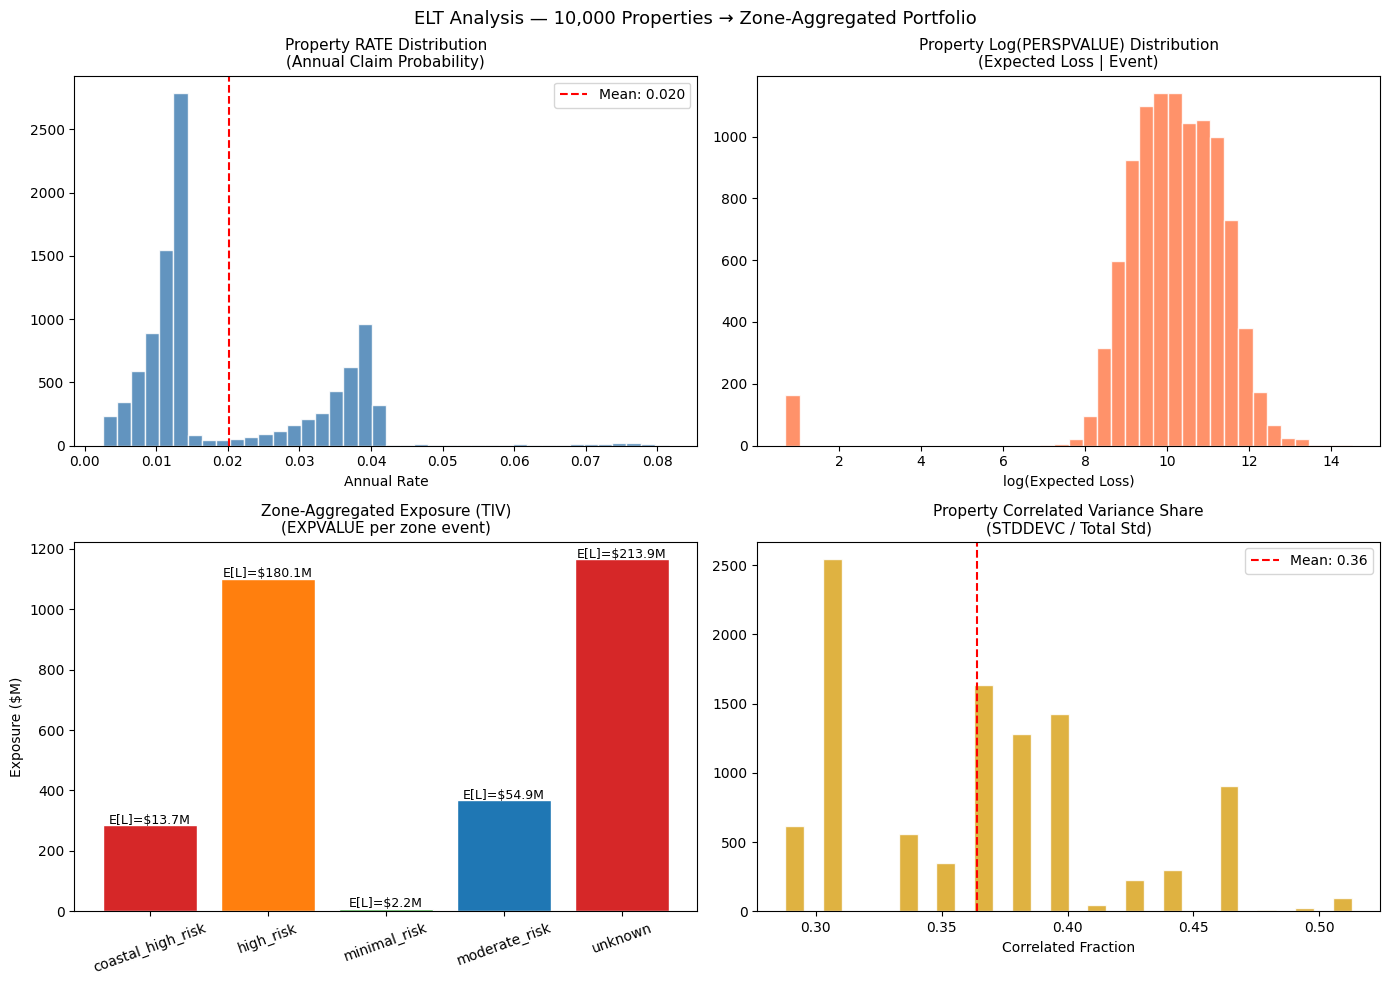

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Property-level RATE distribution
axes[0, 0].hist(prop_elt['RATE'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Property RATE Distribution\n(Annual Claim Probability)', fontsize=11)
axes[0, 0].set_xlabel('Annual Rate')
axes[0, 0].axvline(prop_elt['RATE'].mean(), color='red', linestyle='--',
                    label=f'Mean: {prop_elt["RATE"].mean():.3f}')
axes[0, 0].legend()

# Property-level PERSPVALUE distribution (log scale)
axes[0, 1].hist(np.log1p(prop_elt['PERSPVALUE']), bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Property Log(PERSPVALUE) Distribution\n(Expected Loss | Event)', fontsize=11)
axes[0, 1].set_xlabel('log(Expected Loss)')

# Zone-aggregated ELT: bar chart of exposure by zone
zone_names = [eid.replace('zone_', '') for eid in elt['EVENTID']]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
bars = axes[1, 0].bar(zone_names, elt['EXPVALUE'] / 1e6, color=colors[:len(elt)], edgecolor='white')
axes[1, 0].set_title('Zone-Aggregated Exposure (TIV)\n(EXPVALUE per zone event)', fontsize=11)
axes[1, 0].set_ylabel('Exposure ($M)')
axes[1, 0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, elt['PERSPVALUE'] / 1e6):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    f'E[L]=${val:.1f}M', ha='center', fontsize=9)

# Property-level variance decomposition
corr_share = prop_elt['STDDEVC'] / (prop_elt['STDDEVC'] + prop_elt['STDDEVI']).clip(lower=1e-6)
axes[1, 1].hist(corr_share.clip(0, 1), bins=30, color='goldenrod', edgecolor='white', alpha=0.85)
axes[1, 1].set_title('Property Correlated Variance Share\n(STDDEVC / Total Std)', fontsize=11)
axes[1, 1].set_xlabel('Correlated Fraction')
axes[1, 1].axvline(corr_share.mean(), color='red', linestyle='--',
                    label=f'Mean: {corr_share.mean():.2f}')
axes[1, 1].legend()

plt.suptitle('ELT Analysis — 10,000 Properties → Zone-Aggregated Portfolio', fontsize=13)
plt.tight_layout()
plt.savefig('../data/fig_06_elt_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feed ELT into MarginalPMLEngine (The Round-Trip)

This is the complete end-to-end demonstration: raw property data → ML predictions → ELT → industry-grade PML pricing.

In [8]:
from marginal_pml_kernel import MarginalPMLEngine

print('Running MarginalPMLEngine on ML-generated ELT...')
print('=' * 55)

# MarginalPMLEngine takes return_periods in the constructor,
# then .baseline_pmls returns {RP: PML_value} dict
return_periods = (10, 25, 50, 100, 200, 250, 500)
engine = MarginalPMLEngine(elt, return_periods=return_periods)
results = engine.baseline_pmls

print('\nPML Results (ML-Generated ELT):')
print('-' * 40)
for rp, pml in results.items():
    print(f'  1-in-{rp:>4} year PML:   ${pml:>15,.0f}')

mal = validation['total_mal']
print(f'\n  Mean Annual Loss:    ${mal:>15,.0f}')
tiv = validation['total_exposure']
print(f'  Total Insured Value: ${tiv:>15,.0f}')
print(f'  MAL / TIV:           {mal/tiv:.3%}')

Running MarginalPMLEngine on ML-generated ELT...

PML Results (ML-Generated ELT):
----------------------------------------
  1-in-  10 year PML:   $      8,722,801
  1-in-  25 year PML:   $     90,496,042
  1-in-  50 year PML:   $    209,317,868
  1-in- 100 year PML:   $    318,710,394
  1-in- 200 year PML:   $    412,662,929
  1-in- 250 year PML:   $    440,203,225
  1-in- 500 year PML:   $    518,550,578

  Mean Annual Loss:    $     12,387,610
  Total Insured Value: $  2,928,483,764
  MAL / TIV:           0.423%


## 7. Loss Exceedance Curve

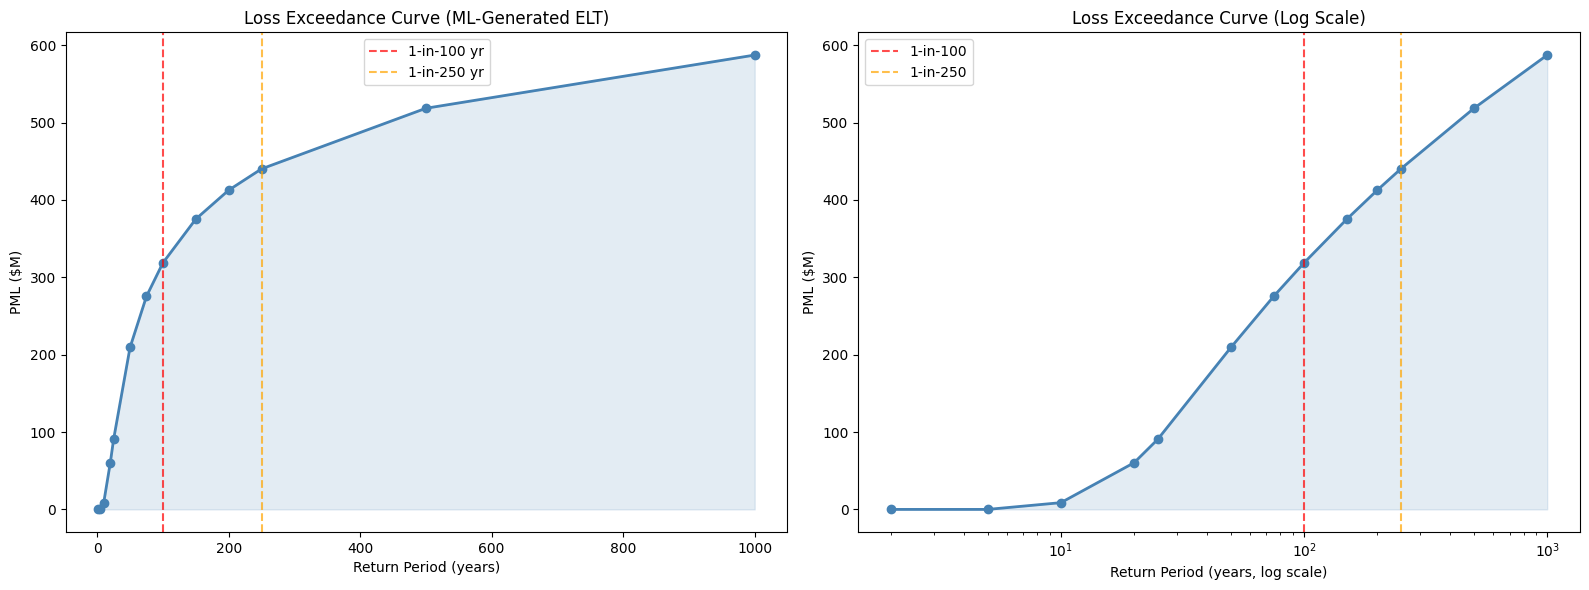


✅ Loss Exceedance Curve generated from ML-predicted ELT


In [9]:
# Build a dense EP curve by re-creating engine with more return periods
dense_rps = (2, 5, 10, 20, 25, 50, 75, 100, 150, 200, 250, 500, 1000)
dense_engine = MarginalPMLEngine(elt, return_periods=dense_rps)
dense_results = dense_engine.baseline_pmls

rps  = list(dense_results.keys())
pmls = list(dense_results.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale
axes[0].plot(rps, [p / 1e6 for p in pmls], 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0].fill_between(rps, [p / 1e6 for p in pmls], alpha=0.15, color='steelblue')
axes[0].set_title('Loss Exceedance Curve (ML-Generated ELT)', fontsize=12)
axes[0].set_xlabel('Return Period (years)')
axes[0].set_ylabel('PML ($M)')
axes[0].axvline(100, color='red', linestyle='--', alpha=0.7, label='1-in-100 yr')
axes[0].axvline(250, color='orange', linestyle='--', alpha=0.7, label='1-in-250 yr')
axes[0].legend()

# Log scale (standard industry format)
axes[1].semilogx(rps, [p / 1e6 for p in pmls], 'o-', color='steelblue', linewidth=2, markersize=6)
axes[1].fill_between(rps, [p / 1e6 for p in pmls], alpha=0.15, color='steelblue')
axes[1].set_title('Loss Exceedance Curve (Log Scale)', fontsize=12)
axes[1].set_xlabel('Return Period (years, log scale)')
axes[1].set_ylabel('PML ($M)')
axes[1].axvline(100, color='red', linestyle='--', alpha=0.7, label='1-in-100')
axes[1].axvline(250, color='orange', linestyle='--', alpha=0.7, label='1-in-250')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/fig_06_loss_exceedance_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Loss Exceedance Curve generated from ML-predicted ELT')

## 8. Compare: ML-Generated ELT vs. Synthetic ELT

In [10]:
# Load the synthetic portfolio ELT from data/portfolio.csv
# The synthetic file uses different column names — map to standard ELT format
SYNTH_COL_MAP = {
    'EventID': 'EVENTID', 'Rate': 'RATE',
    'ExpectedLoss': 'PERSPVALUE', 'MaxExposure': 'EXPVALUE',
    'StdDevC': 'STDDEVC', 'StdDevI': 'STDDEVI',
}
try:
    synthetic_elt = pd.read_csv('../data/portfolio.csv').rename(columns=SYNTH_COL_MAP)
    compare_rps = (50, 100, 250)
    synth_engine  = MarginalPMLEngine(synthetic_elt, return_periods=compare_rps)
    synth_results = synth_engine.baseline_pmls
    ml_engine     = MarginalPMLEngine(elt, return_periods=compare_rps)
    ml_results    = ml_engine.baseline_pmls

    print('PML Comparison — ML-Generated vs Synthetic ELT:')
    print(f'{"Return Period":<20} {"ML-Generated":>18} {"Synthetic":>18}')
    print('-' * 58)
    for rp in compare_rps:
        print(f'  1-in-{rp} year:  {" "*6}  '
              f'${ml_results[rp]:>14,.0f}   ${synth_results[rp]:>14,.0f}')

    print()
    print('→ Both ELTs feed the same engine interchangeably.')
    print('→ ML ELT derived from real FEMA NFIP data + property features.')
    print('→ Synthetic ELT is parametric (for testing when real data not available).')

except FileNotFoundError:
    print('Synthetic portfolio.csv not found. Run scripts/generate_sample_data.py first.')

PML Comparison — ML-Generated vs Synthetic ELT:
Return Period              ML-Generated          Synthetic
----------------------------------------------------------
  1-in-50 year:          $   209,317,868   $     6,333,159
  1-in-100 year:          $   318,710,394   $     7,348,137
  1-in-250 year:          $   440,203,225   $     7,859,724

→ Both ELTs feed the same engine interchangeably.
→ ML ELT derived from real FEMA NFIP data + property features.
→ Synthetic ELT is parametric (for testing when real data not available).


## 9. Save ELT Output

In [11]:
# Save zone-aggregated ELT (used by PML engine)
output_path = Path('../data/ml_generated_elt.csv')
elt.to_csv(output_path, index=False)

# Also save property-level ELT (useful for account-level analysis)
prop_output = Path('../data/ml_generated_elt_property.csv')
prop_elt.to_csv(prop_output, index=False)

print(f'Zone-aggregated ELT saved to: {output_path} ({len(elt):,} rows)')
print(f'Property-level ELT saved to:  {prop_output} ({len(prop_elt):,} rows)')
print(f'\nTo use in the Streamlit workbench:')
print(f'  streamlit run ../src/workbench.py')
print(f'  Then upload: {output_path.name}')

print()
print('=' * 60)
print('✅ FULL PIPELINE COMPLETE')
print('=' * 60)
print('''
  OpenFEMA NFIP Claims
       ↓  data_ingestion.py
  Enriched Claims + NOAA Storms
       ↓  feature_engineering.py
  17-Feature Matrix
       ↓  severity_model.py
  log(E[loss | claim])  ←→  freq_model: P(claim)
       ↓  elt_generator.py
  Event Loss Table (RATE · PERSPVALUE · EXPVALUE · STDDEVC · STDDEVI)
       ↓  marginal_pml_kernel.py
  PML at Return Periods + Loss Exceedance Curve
       ↓  workbench.py
  Streamlit Dashboard + SHAP Explainability
''')

Zone-aggregated ELT saved to: ..\data\ml_generated_elt.csv (5 rows)
Property-level ELT saved to:  ..\data\ml_generated_elt_property.csv (10,000 rows)

To use in the Streamlit workbench:
  streamlit run ../src/workbench.py
  Then upload: ml_generated_elt.csv

✅ FULL PIPELINE COMPLETE

  OpenFEMA NFIP Claims
       ↓  data_ingestion.py
  Enriched Claims + NOAA Storms
       ↓  feature_engineering.py
  17-Feature Matrix
       ↓  severity_model.py
  log(E[loss | claim])  ←→  freq_model: P(claim)
       ↓  elt_generator.py
  Event Loss Table (RATE · PERSPVALUE · EXPVALUE · STDDEVC · STDDEVI)
       ↓  marginal_pml_kernel.py
  PML at Return Periods + Loss Exceedance Curve
       ↓  workbench.py
  Streamlit Dashboard + SHAP Explainability

